<a href="https://colab.research.google.com/github/Amellalakari/Python-projects/blob/main/coronary%20risk%20assesment%20model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi


Sun Sep 20 17:14:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install -q monai nnunetv2 nibabel SimpleITK matplotlib kaggle

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.1/291.1 kB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.8/102.8 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.8/76.8 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.1/28.1 MB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 97.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.4/96.4 kB 7.9 MB/s eta 0:00:00


In [3]:
from google.colab import files

files.upload()

{}

In [8]:
import os

os.makedirs("/root/.kaggle", exist_ok=True)

username = "aishwaryamellalakari"
token = "KGAT_daccdf4f98c46203e0c89758be0106bb"

with open("/root/.kaggle/kaggle.json", "w") as f:
    f.write(f'{{"username":"{username}","key":"{token}"}}')

!chmod 600 /root/.kaggle/kaggle.json

print("Kaggle credentials configured")




Kaggle credentials configured


In [9]:
!cat /root/.kaggle/kaggle.json

{"username":"aishwaryamellalakari","key":"KGAT_daccdf4f98c46203e0c89758be0106bb"}

In [10]:
!kaggle datasets list -s imagecas


ref                                      title                            size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------  ------------------------  -----------  --------------------------  -------------  ---------  ---------------  
xiaoweixumedicalai/imagecas              ImageCAS                  89108870662  2023-11-30 00:07:14.497000          26386         98                1  
ahmedreda1609/imagecas-sample            ImageCAS Sample              95926678  2025-05-17 16:01:20.303000             27          1            0.375  
shakthipraveen/imagecas-600-800          imageCAS 600-800          17298465213  2026-03-06 13:48:22.007000            163          1             0.25  
rj1007/imagecas                          ImageCAS                   5411071455  2026-04-08 04:09:23.847000            134          0             0.25  
shakthipraveen/imagecas-dataset-200-400  ImageCAS Dataset 200-400  17710636239  2026-03-

In [11]:
!df -h

Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   48G   65G  43% /
tmpfs            64M     0   64M   0% /dev
shm             5.7G     0  5.7G   0% /dev/shm
/dev/root       2.0G  1.3G  696M  65% /usr/sbin/docker-init
tmpfs           6.4G  1.2M  6.4G   1% /var/colab
/dev/sda1       119G   53G   67G  45% /kaggle/input
tmpfs           6.4G     0  6.4G   0% /proc/acpi
tmpfs           6.4G     0  6.4G   0% /proc/scsi
tmpfs           6.4G     0  6.4G   0% /sys/firmware


In [12]:
!kaggle datasets download -d ahmedreda1609/imagecas-sample

Dataset URL: https://www.kaggle.com/datasets/ahmedreda1609/imagecas-sample
License(s): MIT
100% 91.5M/91.5M [00:01<00:00, 94.4MB/s]



In [13]:
!unzip imagecas-sample.zip -d imagecas_sample

Archive:  imagecas-sample.zip
  inflating: imagecas_sample/1.img.nii.gz.keep  
  inflating: imagecas_sample/1.label.nii.gz.keep  


In [15]:
!find imagecas_sample | head -30

imagecas_sample
imagecas_sample/1.img.nii.gz.keep
imagecas_sample/1.label.nii.gz.keep


In [16]:
!mv imagecas_sample/1.img.nii.gz.keep imagecas_sample/1.img.nii.gz
!mv imagecas_sample/1.label.nii.gz.keep imagecas_sample/1.label.nii.gz

In [17]:
import nibabel as nib

img = nib.load("imagecas_sample/1.img.nii.gz")

data = img.get_fdata()

print("Shape:", data.shape)
print("Min:", data.min())
print("Max:", data.max())

Shape: (512, 512, 275)
Min: -1024.0
Max: 3071.0


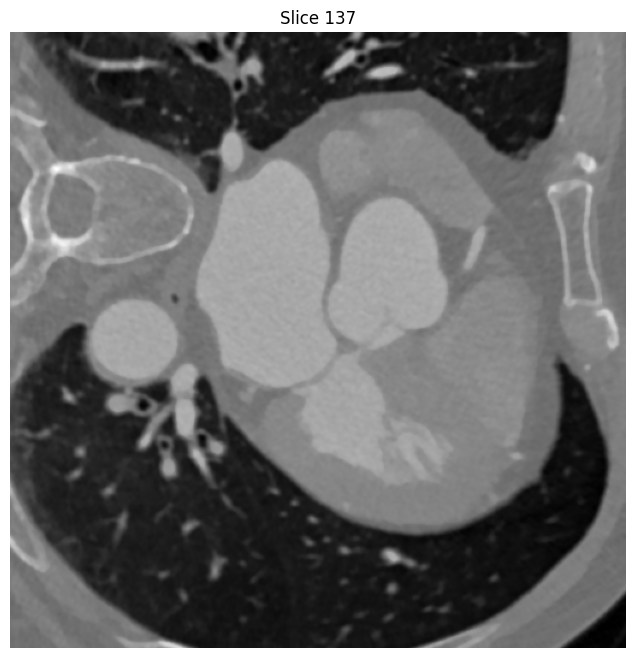

In [18]:
import matplotlib.pyplot as plt

slice_num = data.shape[2] // 2

plt.figure(figsize=(8,8))
plt.imshow(data[:,:,slice_num], cmap="gray")
plt.title(f"Slice {slice_num}")
plt.axis("off")
plt.show()

In [19]:
mask = nib.load("imagecas_sample/1.label.nii.gz")

mask_data = mask.get_fdata()

print("Mask shape:", mask_data.shape)
print("Unique values:", set(mask_data.flatten()))

Mask shape: (512, 512, 275)
Unique values: {np.float64(0.0), np.float64(1.0)}


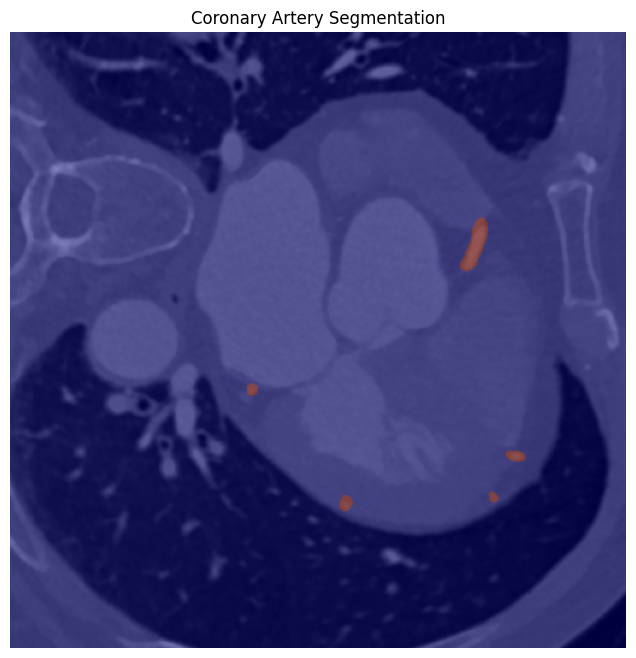

In [20]:
plt.figure(figsize=(8,8))

plt.imshow(data[:,:,slice_num], cmap="gray")

plt.imshow(
    mask_data[:,:,slice_num],
    cmap="jet",
    alpha=0.5
)

plt.title("Coronary Artery Segmentation")
plt.axis("off")
plt.show()

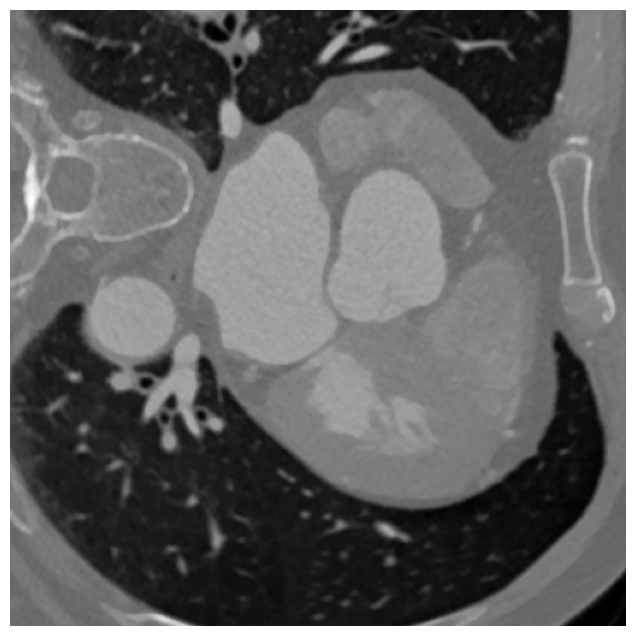

In [21]:
import matplotlib.pyplot as plt

slice_num = 140

plt.figure(figsize=(8,8))
plt.imshow(data[:,:,slice_num], cmap="gray")
plt.axis("off")
plt.show()

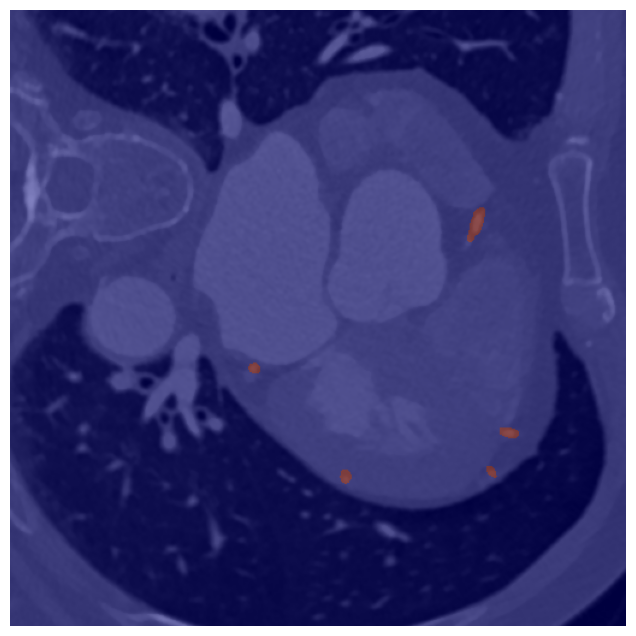

In [22]:
plt.figure(figsize=(8,8))

plt.imshow(data[:,:,slice_num], cmap="gray")

plt.imshow(
    mask_data[:,:,slice_num],
    cmap="jet",
    alpha=0.5
)

plt.axis("off")
plt.show()

In [23]:
import numpy as np

artery_slices = []

for i in range(mask_data.shape[2]):
    if np.sum(mask_data[:,:,i]) > 0:
        artery_slices.append(i)

print("First artery slice:", artery_slices[0])
print("Last artery slice:", artery_slices[-1])
print("Number of slices containing arteries:", len(artery_slices))

First artery slice: 17
Last artery slice: 182
Number of slices containing arteries: 166


In [24]:
import numpy as np

artery_pixels = []

for i in range(mask_data.shape[2]):
    artery_pixels.append(np.sum(mask_data[:, :, i]))

best_slice = np.argmax(artery_pixels)

print("Best slice:", best_slice)
print("Pixels:", artery_pixels[best_slice])

Best slice: 171
Pixels: 2075.0


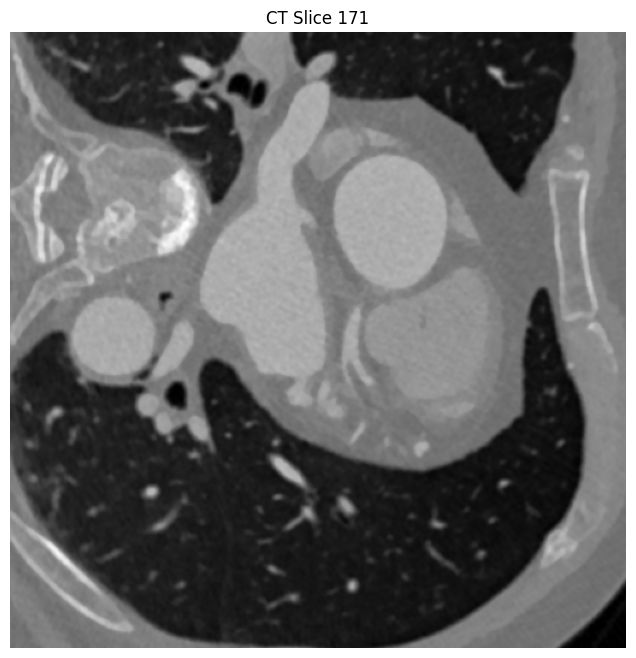

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
plt.imshow(data[:, :, best_slice], cmap="gray")
plt.title(f"CT Slice {best_slice}")
plt.axis("off")
plt.show()

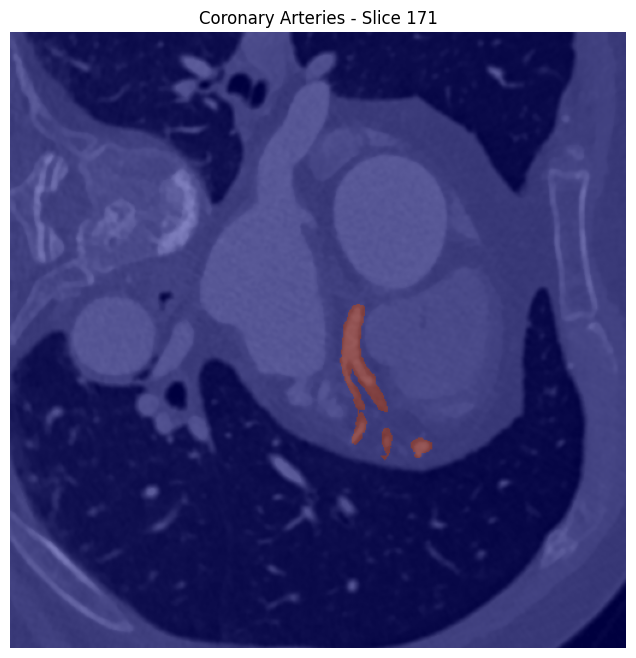

In [26]:
plt.figure(figsize=(8,8))

plt.imshow(data[:, :, best_slice], cmap="gray")

plt.imshow(
    mask_data[:, :, best_slice],
    cmap="jet",
    alpha=0.5
)

plt.title(f"Coronary Arteries - Slice {best_slice}")
plt.axis("off")
plt.show()

In [27]:
print(img.header.get_zooms())

(np.float32(0.37695312), np.float32(0.37695312), np.float32(0.5))


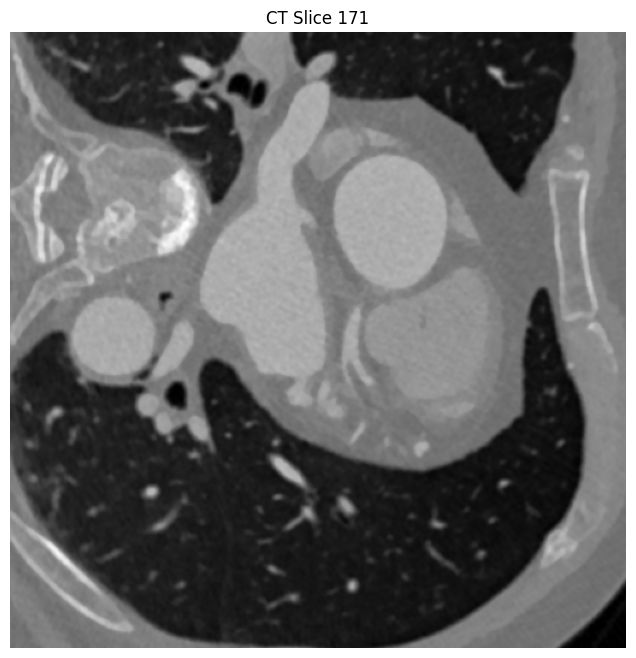

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
plt.imshow(data[:, :, 171], cmap="gray")
plt.title("CT Slice 171")
plt.axis("off")
plt.show()

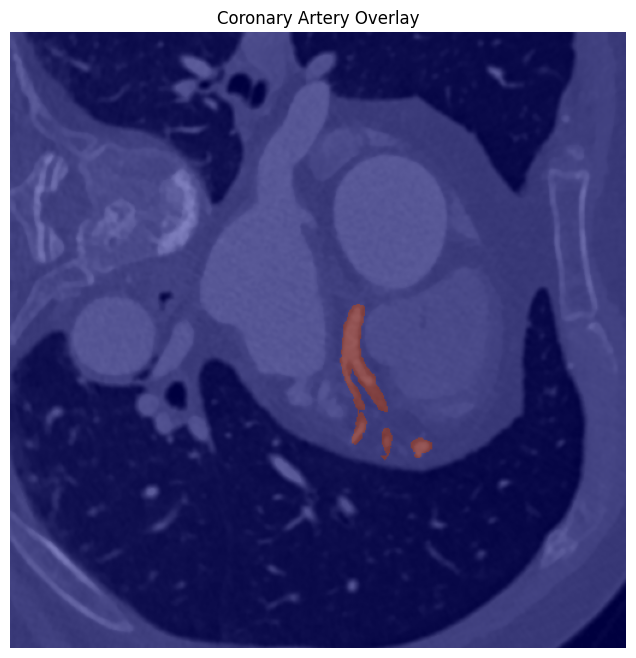

In [29]:
plt.figure(figsize=(8,8))

plt.imshow(data[:, :, 171], cmap="gray")

plt.imshow(
    mask_data[:, :, 171],
    cmap="jet",
    alpha=0.5
)

plt.title("Coronary Artery Overlay")
plt.axis("off")
plt.show()

In [31]:
import numpy as np

windowed = np.clip(data, -100, 800)

In [32]:
print(windowed.min())
print(windowed.max())

-100.0
800.0


In [33]:
normalized = (windowed + 100) / 900

In [34]:
print(normalized.min())
print(normalized.max())

0.0
1.0


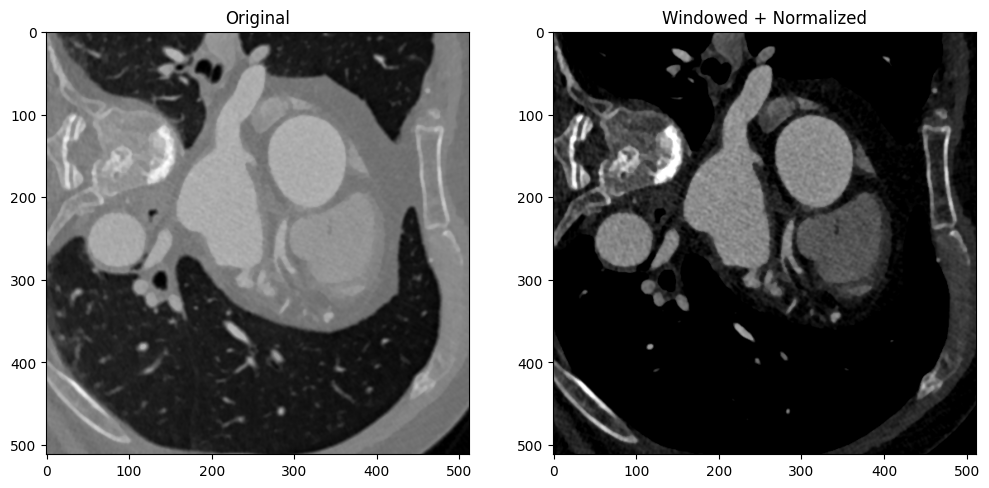

In [35]:
fig, ax = plt.subplots(1,2, figsize=(12,6))

ax[0].imshow(data[:,:,171], cmap="gray")
ax[0].set_title("Original")

ax[1].imshow(normalized[:,:,171], cmap="gray")
ax[1].set_title("Windowed + Normalized")

plt.show()

In [36]:
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    ScaleIntensityRanged
)

transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),

    ScaleIntensityRanged(
        keys=["image"],
        a_min=-100,
        a_max=800,
        b_min=0.0,
        b_max=1.0,
        clip=True
    )
])

data_dict = [{
    "image": "imagecas_sample/1.img.nii.gz",
    "label": "imagecas_sample/1.label.nii.gz"
}]

In [37]:
sample = transforms(data_dict[0])

print(sample["image"].shape)
print(sample["label"].shape)

torch.Size([1, 512, 512, 275])
torch.Size([1, 512, 512, 275])


In [38]:
print(sample["image"].min())
print(sample["image"].max())

metatensor(0.)
metatensor(1.)


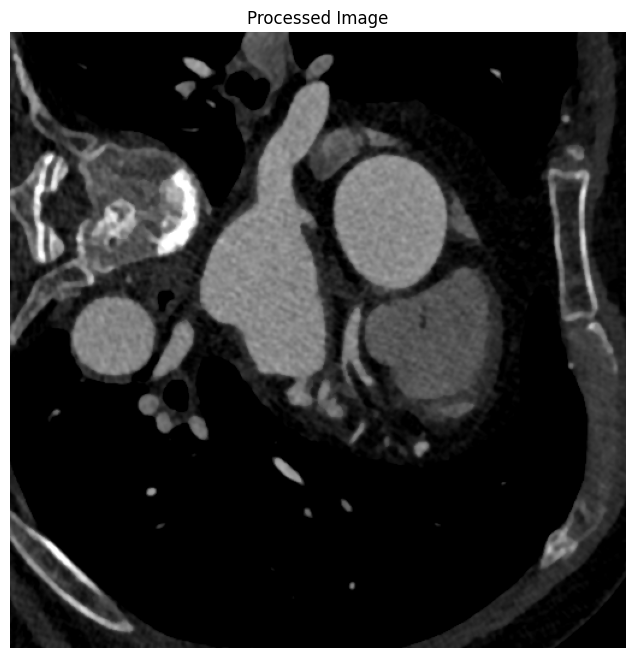

In [39]:
import matplotlib.pyplot as plt

img_processed = sample["image"][0]

plt.figure(figsize=(8,8))
plt.imshow(img_processed[:,:,171], cmap="gray")
plt.title("Processed Image")
plt.axis("off")
plt.show()

In [40]:
print(sample["image"].shape)
print(sample["label"].shape)

torch.Size([1, 512, 512, 275])
torch.Size([1, 512, 512, 275])


In [41]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [42]:
img = sample["image"]
label = sample["label"]

img_patch = img[:, 150:278, 150:278, 120:184]
label_patch = label[:, 150:278, 150:278, 120:184]

print(img_patch.shape)
print(label_patch.shape)

torch.Size([1, 128, 128, 64])
torch.Size([1, 128, 128, 64])


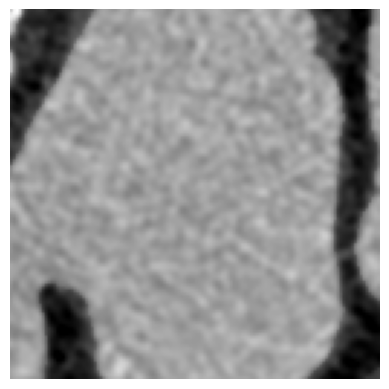

In [43]:
import matplotlib.pyplot as plt

plt.imshow(
    img_patch[0,:,:,32],
    cmap="gray"
)

plt.axis("off")
plt.show()

In [44]:
from monai.networks.nets import UNet

model = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=1,
    channels=(16,32,64),
    strides=(2,2),
)

print(model)

UNet(
  (model): Sequential(
    (0): Convolution(
      (conv): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
      (adn): ADN(
        (N): InstanceNorm3d(16, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
        (D): Dropout(p=0.0, inplace=False)
        (A): PReLU(num_parameters=1)
      )
    )
    (1): SkipConnection(
      (submodule): Sequential(
        (0): Convolution(
          (conv): Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
          (adn): ADN(
            (N): InstanceNorm3d(32, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
            (D): Dropout(p=0.0, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
        (1): SkipConnection(
          (submodule): Convolution(
            (conv): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
            (adn): ADN(
              (N): InstanceNorm3d(64, eps=1e-05, momentum=

In [45]:
device = torch.device("cuda")

model = model.to(device)

In [46]:
x = img_patch.unsqueeze(0).float().to(device)

y = label_patch.unsqueeze(0).float().to(device)

print(x.shape)
print(y.shape)

torch.Size([1, 1, 128, 128, 64])
torch.Size([1, 1, 128, 128, 64])


In [47]:
with torch.no_grad():
    pred = model(x)

print(pred.shape)

torch.Size([1, 1, 128, 128, 64])


In [48]:
print(torch.cuda.get_device_name(0))

Tesla T4


In [49]:
img = sample["image"]
label = sample["label"]

img_patch = img[:, 150:278, 150:278, 120:184]
label_patch = label[:, 150:278, 150:278, 120:184]

print(img_patch.shape)
print(label_patch.shape)

torch.Size([1, 128, 128, 64])
torch.Size([1, 128, 128, 64])


In [50]:
from monai.networks.nets import UNet

model = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=1,
    channels=(16, 32, 64),
    strides=(2, 2),
)

print("Model created")

Model created


In [51]:
import torch

device = torch.device("cuda")

model = model.to(device)

print("Using:", device)

Using: cuda


In [52]:
x = img_patch.unsqueeze(0).float().to(device)
y = label_patch.unsqueeze(0).float().to(device)

print(x.shape)
print(y.shape)

torch.Size([1, 1, 128, 128, 64])
torch.Size([1, 1, 128, 128, 64])


In [53]:
with torch.no_grad():
    pred = model(x)

print(pred.shape)

torch.Size([1, 1, 128, 128, 64])


In [54]:
from monai.losses import DiceLoss

loss_function = DiceLoss(sigmoid=True)

loss = loss_function(pred, y)

print("Initial Dice Loss:", loss.item())

Initial Dice Loss: 0.9962788224220276


In [55]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [56]:
model.train()

optimizer.zero_grad()

pred = model(x)

loss = loss_function(pred, y)

loss.backward()

optimizer.step()

print("Training loss:", loss.item())

Training loss: 0.9962788224220276


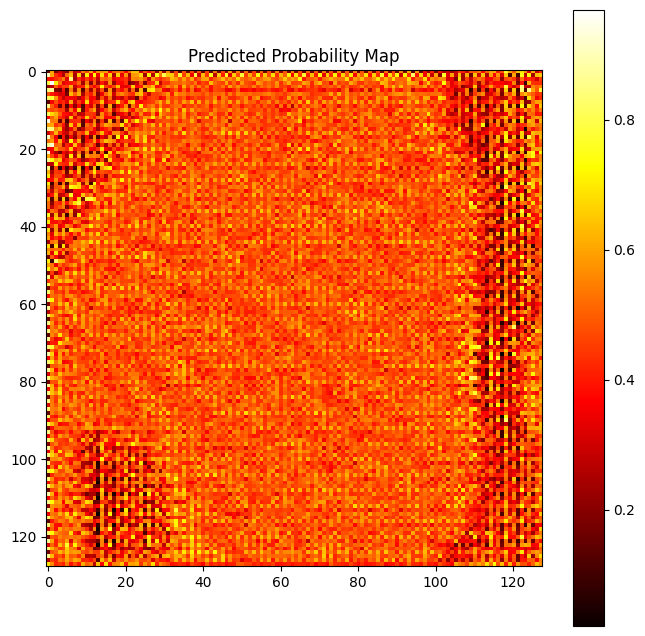

In [57]:
import matplotlib.pyplot as plt

pred_prob = torch.sigmoid(pred)

pred_slice = pred_prob[0,0,:,:,32].detach().cpu()

plt.figure(figsize=(8,8))
plt.imshow(pred_slice, cmap="hot")
plt.title("Predicted Probability Map")
plt.colorbar()
plt.show()

In [58]:
print("Positive voxels:", label_patch.sum().item())

Positive voxels: 2193.0


In [59]:
print("Total voxels:", label_patch.numel())

Total voxels: 1048576


In [60]:
from monai.losses import DiceLoss

loss_function = DiceLoss(sigmoid=True)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

for epoch in range(20):

    model.train()

    optimizer.zero_grad()

    pred = model(x)

    loss = loss_function(pred, y)

    loss.backward()

    optimizer.step()

    print(f"Epoch {epoch:02d} | Loss: {loss.item():.4f}")

Epoch 00 | Loss: 0.9962
Epoch 01 | Loss: 0.9954
Epoch 02 | Loss: 0.9949
Epoch 03 | Loss: 0.9944
Epoch 04 | Loss: 0.9940
Epoch 05 | Loss: 0.9937
Epoch 06 | Loss: 0.9932
Epoch 07 | Loss: 0.9929
Epoch 08 | Loss: 0.9925
Epoch 09 | Loss: 0.9922
Epoch 10 | Loss: 0.9920
Epoch 11 | Loss: 0.9918
Epoch 12 | Loss: 0.9916
Epoch 13 | Loss: 0.9914
Epoch 14 | Loss: 0.9912
Epoch 15 | Loss: 0.9911
Epoch 16 | Loss: 0.9909
Epoch 17 | Loss: 0.9907
Epoch 18 | Loss: 0.9905
Epoch 19 | Loss: 0.9904


In [63]:
MONAI UNet

SyntaxError: invalid syntax (2406026188.py, line 1)

In [64]:
SwinUNETR

NameError: name 'SwinUNETR' is not defined

In [66]:
!kaggle datasets download -d jauadahmedsadik/1-200catimg

Dataset URL: https://www.kaggle.com/datasets/jauadahmedsadik/1-200catimg
License(s): unknown
100% 16.0G/16.0G [04:57<00:00, 57.8MB/s]



In [67]:
!unzip 1-200catimg.zip -d imagecas_1_200

Archive:  1-200catimg.zip
  inflating: imagecas_1_200/imagecas/1-200.z01/1-200.z01  
  inflating: imagecas_1_200/imagecas/1-200.z02/1-200.z02  
  inflating: imagecas_1_200/imagecas/1-200.z03/1-200.z03  
  inflating: imagecas_1_200/imagecas/1-200.z04/1-200.z04  


In [68]:
!find imagecas_1_200 -type f | head -20

imagecas_1_200/imagecas/1-200.z02/1-200.z02
imagecas_1_200/imagecas/1-200.z03/1-200.z03
imagecas_1_200/imagecas/1-200.z01/1-200.z01
imagecas_1_200/imagecas/1-200.z04/1-200.z04


In [69]:
!ls -lh imagecas_1_200/imagecas

total 16K
drwxr-xr-x 2 root root 4.0K Sep 20 18:14 1-200.z01
drwxr-xr-x 2 root root 4.0K Sep 20 18:16 1-200.z02
drwxr-xr-x 2 root root 4.0K Sep 20 18:17 1-200.z03
drwxr-xr-x 2 root root 4.0K Sep 20 18:18 1-200.z04


In [70]:
!find imagecas_1_200 -type f | sort

imagecas_1_200/imagecas/1-200.z01/1-200.z01
imagecas_1_200/imagecas/1-200.z02/1-200.z02
imagecas_1_200/imagecas/1-200.z03/1-200.z03
imagecas_1_200/imagecas/1-200.z04/1-200.z04


In [71]:
!du -sh imagecas_1_200

16G	imagecas_1_200


In [72]:
!ls -lh *.zip

-rw-r--r-- 1 root root 17G Sep 27  2025 1-200catimg.zip
-rw-r--r-- 1 root root 92M May 17  2025 imagecas-sample.zip


In [73]:
!unzip -l 1-200catimg.zip | head -50

Archive:  1-200catimg.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
4293918720  2025-09-27 17:02   imagecas/1-200.z01/1-200.z01
4293918720  2025-09-27 17:06   imagecas/1-200.z02/1-200.z02
4293918720  2025-09-27 17:10   imagecas/1-200.z03/1-200.z03
4293918720  2025-09-27 17:15   imagecas/1-200.z04/1-200.z04
---------                     -------
17175674880                     4 files


In [74]:
!file imagecas_1_200/imagecas/1-200.z01/1-200.z01

imagecas_1_200/imagecas/1-200.z01/1-200.z01: Zip multi-volume archive data, at least PKZIP v2.50 to extract


In [75]:
!hexdump -C imagecas_1_200/imagecas/1-200.z01/1-200.z01 | head

00000000  50 4b 07 08 50 4b 03 04  0a 00 00 00 00 00 2e 8b  |PK..PK..........|
00000010  7c 57 00 00 00 00 00 00  00 00 00 00 00 00 06 00  ||W..............|
00000020  00 00 31 2d 32 30 30 2f  50 4b 03 04 14 00 00 00  |..1-200/PK......|
00000030  08 00 01 12 76 54 1d a0  db fb 85 6d b5 05 98 58  |....vT.....m...X|
00000040  b5 05 12 00 00 00 31 2d  32 30 30 2f 31 2e 69 6d  |......1-200/1.im|
00000050  67 2e 6e 69 69 2e 67 7a  00 17 80 e8 7f 1f 8b 08  |g.nii.gz........|
00000060  08 80 56 f0 60 04 ff 64  69 61 6f 5f 30 2e 6e 69  |..V.`..diao_0.ni|
00000070  69 00 c4 bd 65 74 14 59  17 fe 7b 4e 75 02 21 40  |i...et.Y..{Nu.!@|
00000080  20 b8 05 08 c1 dd dd dd  99 81 81 c1 dd 75 06 1d  | ............u..|
00000090  06 77 06 19 9c c1 dd dd  dd 83 05 d7 40 42 02 21  |.w..........@B.!|


In [76]:
!kaggle datasets download -d ahmedreda1609/imagecas-labels-1-1000

Dataset URL: https://www.kaggle.com/datasets/ahmedreda1609/imagecas-labels-1-1000
License(s): MIT
100% 122M/122M [00:01<00:00, 71.3MB/s]



In [77]:
!unzip -l imagecas-labels-1-1000.zip | head -50

Archive:  imagecas-labels-1-1000.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
 27088906  2025-05-07 19:27   1-200_labels.zip.keep
 26919830  2025-05-07 19:28   201-400_labels.zip.keep
 26159011  2025-05-07 19:28   401-600_labels.zip.keep
 26740608  2025-05-07 19:28   601-800_labels.zip.keep
 25974717  2025-05-07 19:28   801-1000_labels.zip.keep
---------                     -------
132883072                     5 files


In [78]:
!mv 1-200_labels.zip.keep 1-200_labels.zip
!unzip -l 1-200_labels.zip | head -30

mv: cannot stat '1-200_labels.zip.keep': No such file or directory
unzip:  cannot find or open 1-200_labels.zip, 1-200_labels.zip.zip or 1-200_labels.zip.ZIP.


In [79]:
!unzip imagecas-labels-1-1000.zip

Archive:  imagecas-labels-1-1000.zip
  inflating: 1-200_labels.zip.keep   
  inflating: 201-400_labels.zip.keep  
  inflating: 401-600_labels.zip.keep  
  inflating: 601-800_labels.zip.keep  
  inflating: 801-1000_labels.zip.keep  


In [80]:
!mv "1-200_labels.zip.keep" "1-200_labels.zip"

In [81]:
!unzip -l "1-200_labels.zip" | head -40

Archive:  1-200_labels.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
        0  2025-05-07 18:21   1-200/
  2337656  2022-03-22 04:09   1-200/69.label.nii.gz
  2468906  2022-03-22 07:49   1-200/199.label.nii.gz
  2600031  2022-03-22 04:12   1-200/71.label.nii.gz
  2334179  2022-03-22 05:53   1-200/131.label.nii.gz
  2600774  2022-03-22 07:53   1-200/200.label.nii.gz
  2594420  2022-03-22 05:41   1-200/124.label.nii.gz
  2623799  2022-03-22 07:34   1-200/190.label.nii.gz
  2598118  2022-03-22 07:26   1-200/185.label.nii.gz
  2608725  2022-03-22 02:44   1-200/19.label.nii.gz
  2606246  2022-03-22 07:05   1-200/172.label.nii.gz
  2136198  2022-03-22 04:13   1-200/73.label.nii.gz
  2612629  2022-03-22 07:18   1-200/179.label.nii.gz
  2435798  2022-03-22 07:08   1-200/174.label.nii.gz
  2153246  2022-03-22 04:14   1-200/74.label.nii.gz
  2569854  2022-03-22 04:29   1-200/83.label.nii.gz
  2614811  2022-03-22 05:31   1-200/118.label.nii.gz
  2594130  2022-03-22 06

In [82]:
!unzip "1-200_labels.zip" -d labels_1_200

Archive:  1-200_labels.zip
   creating: labels_1_200/1-200/
  inflating: labels_1_200/1-200/69.label.nii.gz  
  inflating: labels_1_200/1-200/199.label.nii.gz  
  inflating: labels_1_200/1-200/71.label.nii.gz  
  inflating: labels_1_200/1-200/131.label.nii.gz  
  inflating: labels_1_200/1-200/200.label.nii.gz  
  inflating: labels_1_200/1-200/124.label.nii.gz  
  inflating: labels_1_200/1-200/190.label.nii.gz  
  inflating: labels_1_200/1-200/185.label.nii.gz  
  inflating: labels_1_200/1-200/19.label.nii.gz  
  inflating: labels_1_200/1-200/172.label.nii.gz  
  inflating: labels_1_200/1-200/73.label.nii.gz  
  inflating: labels_1_200/1-200/179.label.nii.gz  
  inflating: labels_1_200/1-200/174.label.nii.gz  
  inflating: labels_1_200/1-200/74.label.nii.gz  
  inflating: labels_1_200/1-200/83.label.nii.gz  
  inflating: labels_1_200/1-200/118.label.nii.gz  
  inflating: labels_1_200/1-200/153.label.nii.gz  
  inflating: labels_1_200/1-200/72.label.nii.gz  
  inflating: labels_1_200/1-2

In [83]:
!find labels_1_200 -name "*.nii.gz" | wc -l

200


In [85]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [86]:
!mkdir -p "/content/drive/MyDrive/ImageCAS_Project"

In [87]:
!cp "1-200_labels.zip" "/content/drive/MyDrive/ImageCAS_Project/"

In [88]:
!cp -r labels_1_200 "/content/drive/MyDrive/ImageCAS_Project/"

In [89]:
import nibabel as nib
import numpy as np

mask = nib.load(
    "labels_1_200/1-200/1.label.nii.gz"
)

mask_data = mask.get_fdata()

print(mask_data.shape)
print(np.unique(mask_data))

(512, 512, 275)
[0. 1.]
